<a href="https://colab.research.google.com/github/Redcom1988/ann-butterfly-recognition/blob/main/annglcmhyperparameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import os
import cv2
import zipfile
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import math
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import skimage.feature as skf

In [5]:
from google.colab import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('kaggleName')
os.environ['KAGGLE_KEY'] = userdata.get('kaggleKey')

!kaggle datasets download -d phucthaiv02/butterfly-image-classification
!unzip -q butterfly-image-classification.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification
License(s): CC0-1.0
butterfly-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace dataset/Testing_set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace dataset/Training_set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [6]:
def load_images_from_csv(csv_path, image_folder, target_size=(96, 96), max_samples_per_class=200):
    df = pd.read_csv(csv_path)
    class_names = sorted(df['label'].unique())
    label_dict = {name: idx for idx, name in enumerate(class_names)}

    images, labels = [], []
    counter = {cls: 0 for cls in class_names}

    for _, row in df.iterrows():
        filename = row['filename']
        label = row['label']
        if counter[label] >= max_samples_per_class:
            continue

        img_path = os.path.join(image_folder, filename)
        if not os.path.exists(img_path):
            print(f"File not found: {img_path}")
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size)
        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(label_dict[label])
        counter[label] += 1

    return np.array(images), np.array(labels), class_names, label_dict

csv_path = "dataset/Training_set.csv"
image_folder = "dataset/train"
images, labels, class_names, label_dict = load_images_from_csv(csv_path, image_folder)

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [7]:
def calculate_glcm(image, distance=1, angle=0, levels=256):
    offset_x = int(round(distance * math.cos(angle)))
    offset_y = int(round(distance * math.sin(angle)))
    glcm = np.zeros((levels, levels), dtype=np.uint32)

    height, width = image.shape
    for y in range(max(-offset_y, 0), min(height, height - offset_y)):
        for x in range(max(-offset_x, 0), min(width, width - offset_x)):
            i = image[y, x]
            j = image[y + offset_y, x + offset_x]
            glcm[i, j] += 1
            glcm[j, i] += 1

    glcm = glcm.astype(np.float32)
    if np.sum(glcm) > 0:
        glcm /= np.sum(glcm)
    return glcm

def extract_glcm_features(images, distances=[1, 2, 3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=16):
    features = []
    for idx, img in enumerate(images):
        if idx % 100 == 0:
            print(f"Processing image {idx+1}/{len(images)}")

        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gray = (gray * (levels - 1)).astype(np.uint8)
        glcm_features = []

        for d in distances:
            for a in angles:
                glcm = calculate_glcm(gray, d, a, levels)
                i, j = np.indices(glcm.shape)

                # More GLCM statistics
                contrast = np.sum((i - j)**2 * glcm)
                energy = np.sum(glcm**2)
                homogeneity = np.sum(glcm / (1 + (i - j)**2))
                entropy = -np.sum(glcm * np.log2(glcm + 1e-10))

                mean_i = np.sum(i * np.sum(glcm, axis=1))
                mean_j = np.sum(j * np.sum(glcm, axis=0))
                std_i = np.sqrt(np.sum((i - mean_i)**2 * np.sum(glcm, axis=1))) + 1e-8
                std_j = np.sqrt(np.sum((j - mean_j)**2 * np.sum(glcm, axis=0))) + 1e-8
                correlation = np.sum((i - mean_i) * (j - mean_j) * glcm) / (std_i * std_j)

                glcm_features.extend([contrast, energy, homogeneity, correlation, entropy])

        # Add color histograms (3 channels, 8 bins each)
        for channel in range(3):
            hist, _ = np.histogram(img[:,:,channel], bins=8, range=(0, 1))
            glcm_features.extend(hist / np.sum(hist))

        # Add simple edge features
        sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        edge_mag = np.sqrt(sobel_x**2 + sobel_y**2)
        edge_features = [np.mean(edge_mag), np.std(edge_mag)]
        glcm_features.extend(edge_features)

        features.append(glcm_features)
    return np.array(features)

# Apply PCA to reduce feature dimensions
def apply_pca(train_features, test_features, n_components=0.95):
    print("Applying PCA...")
    pca = PCA(n_components=n_components)
    train_reduced = pca.fit_transform(train_features)
    test_reduced = pca.transform(test_features)
    print(f"Reduced from {train_features.shape[1]} to {train_reduced.shape[1]} features")
    return train_reduced, test_reduced, pca

In [8]:
# Extract enhanced features
print("Extracting GLCM features for training set...")
glcm_train = extract_glcm_features(X_train)
print("Extracting GLCM features for test set...")
glcm_test = extract_glcm_features(X_test)

# Flatten images and combine with GLCM
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_combined = np.hstack([X_train_flat, glcm_train])
X_test_combined = np.hstack([X_test_flat, glcm_test])

# Apply PCA
X_train_reduced, X_test_reduced, pca = apply_pca(X_train_combined, X_test_combined, n_components=100)

# Normalize
scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_reduced)
X_test_combined = scaler.transform(X_test_reduced)

Extracting GLCM features for training set...
Processing image 1/5199
Processing image 101/5199
Processing image 201/5199
Processing image 301/5199
Processing image 401/5199
Processing image 501/5199
Processing image 601/5199
Processing image 701/5199
Processing image 801/5199
Processing image 901/5199
Processing image 1001/5199
Processing image 1101/5199
Processing image 1201/5199
Processing image 1301/5199
Processing image 1401/5199
Processing image 1501/5199
Processing image 1601/5199
Processing image 1701/5199
Processing image 1801/5199
Processing image 1901/5199
Processing image 2001/5199
Processing image 2101/5199
Processing image 2201/5199
Processing image 2301/5199
Processing image 2401/5199
Processing image 2501/5199
Processing image 2601/5199
Processing image 2701/5199
Processing image 2801/5199
Processing image 2901/5199
Processing image 3001/5199
Processing image 3101/5199
Processing image 3201/5199
Processing image 3301/5199
Processing image 3401/5199
Processing image 3501/

In [9]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_layers, output_size, dropout_rates=None, lambd=0.001):
        self.layer_sizes = [input_size] + hidden_layers + [output_size]
        self.num_layers = len(self.layer_sizes) - 1
        self.weights = []
        self.biases = []
        self.dropout_rates = dropout_rates or [0.0] * self.num_layers
        self.lambd = lambd

        # Initialize weights with He initialization
        for i in range(self.num_layers):
            w = np.random.randn(self.layer_sizes[i], self.layer_sizes[i+1]) * np.sqrt(2.0 / self.layer_sizes[i])
            b = np.zeros((1, self.layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return (x > 0).astype(np.float32)

    def leaky_relu(self, x, alpha=0.01):
        return np.maximum(alpha * x, x)

    def leaky_relu_deriv(self, x, alpha=0.01):
        dx = np.ones_like(x)
        dx[x < 0] = alpha
        return dx

    def softmax(self, x):
        exps = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exps / np.sum(exps, axis=1, keepdims=True)

    def forward(self, X, training=False):
        self.activations = [X]
        self.zs = []
        self.dropout_masks = []

        # Forward through hidden layers
        for i in range(self.num_layers - 1):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            self.zs.append(z)
            a = self.leaky_relu(z)

            if training and self.dropout_rates[i] > 0:
                mask = np.random.rand(*a.shape) > self.dropout_rates[i]
                a = a * mask / (1 - self.dropout_rates[i])
                self.dropout_masks.append(mask)
            else:
                self.dropout_masks.append(None)

            self.activations.append(a)

        # Output layer with softmax
        z = np.dot(self.activations[-1], self.weights[-1]) + self.biases[-1]
        self.zs.append(z)
        a = self.softmax(z)
        self.activations.append(a)

        return self.activations[-1]

    def backward(self, X, y_true, y_pred, lr):
        m = X.shape[0]
        grads_w = [0] * self.num_layers
        grads_b = [0] * self.num_layers

        # Output layer gradient
        delta = y_pred - y_true
        grads_w[-1] = np.dot(self.activations[-2].T, delta) / m + (self.lambd * self.weights[-1] / m)
        grads_b[-1] = np.sum(delta, axis=0, keepdims=True) / m

        # Hidden layers
        for i in range(self.num_layers - 2, -1, -1):
            delta = np.dot(delta, self.weights[i+1].T)
            if self.dropout_masks[i] is not None:
                delta = delta * self.dropout_masks[i] / (1 - self.dropout_rates[i])
            delta = delta * self.leaky_relu_deriv(self.zs[i])
            grads_w[i] = np.dot(self.activations[i].T, delta) / m + (self.lambd * self.weights[i] / m)
            grads_b[i] = np.sum(delta, axis=0, keepdims=True) / m

        # Apply gradients
        for i in range(self.num_layers):
            self.weights[i] -= lr * grads_w[i]
            self.biases[i] -= lr * grads_b[i]

    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        log_likelihood = -np.log(np.sum(y_pred * y_true, axis=1) + 1e-10)

        # L2 regularization
        reg_loss = 0
        for i in range(self.num_layers):
            reg_loss += np.sum(self.weights[i]**2)

        return np.sum(log_likelihood)/m + (self.lambd / (2 * m)) * reg_loss

    def predict(self, X):
        y_pred = self.forward(X, training=False)
        return np.argmax(y_pred, axis=1)

In [10]:
def one_hot_encode(y, num_classes):
    encoded = np.zeros((y.size, num_classes))
    encoded[np.arange(y.size), y] = 1
    return encoded

num_classes = len(class_names)
y_train_onehot = one_hot_encode(y_train, num_classes)
y_test_onehot = one_hot_encode(y_test, num_classes)

# Split with one-hot encoded labels
X_train_tune, X_val, y_train_tune_onehot, y_val_onehot = train_test_split(
    X_train_combined, y_train_onehot, test_size=0.2, random_state=42
)

# Also get the non-onehot version for accuracy calculation
_, _, y_train_tune, y_val = train_test_split(
    X_train_combined, y_train, test_size=0.2, random_state=42
)

In [11]:
param_grid = {
    'learning_rate': [0.01, 0.005],
    'hidden_layers': [[256, 128], [128, 64]],
    'dropout_rates': [[0.3, 0.3], [0.5, 0.3]],
    'lambd': [0.001, 0.0005]
}

def hyperparameter_tuning(X_train, y_train_onehot, y_train, X_val, y_val_onehot, y_val, param_grid, epochs=10, batch_size=32):
    best_params = None
    best_acc = 0

    print("Starting hyperparameter tuning...")

    for lr in param_grid['learning_rate']:
        for hidden_layers in param_grid['hidden_layers']:
            for dropout_rates in param_grid['dropout_rates']:
                for l2 in param_grid['lambd']:
                    print(f"Testing: lr={lr}, hidden={hidden_layers}, dropout={dropout_rates}, lambda={l2}")

                    model = NeuralNetwork(
                        input_size=X_train.shape[1],
                        hidden_layers=hidden_layers,
                        output_size=num_classes,
                        dropout_rates=dropout_rates,
                        lambd=l2
                    )

                    for epoch in range(epochs):
                        indices = np.random.permutation(len(X_train))
                        for i in range(0, len(X_train), batch_size):
                            batch = indices[i:i+batch_size]
                            Xb, yb_onehot = X_train[batch], y_train_onehot[batch]
                            y_pred = model.forward(Xb, training=True)
                            model.backward(Xb, yb_onehot, y_pred, lr)

                    val_acc = np.mean(model.predict(X_val) == y_val)
                    print(f"Validation accuracy: {val_acc:.4f}")

                    if val_acc > best_acc:
                        best_acc = val_acc
                        best_params = {
                            'learning_rate': lr,
                            'hidden_layers': hidden_layers,
                            'dropout_rates': dropout_rates,
                            'lambd': l2
                        }

    print(f"Best parameters: {best_params}, best accuracy: {best_acc:.4f}")
    return best_params

# Train with best parameters
best_params = hyperparameter_tuning(X_train_tune, y_train_tune_onehot, y_train_tune,
                                  X_val, y_val_onehot, y_val, param_grid)

Starting hyperparameter tuning...
Testing: lr=0.01, hidden=[256, 128], dropout=[0.3, 0.3], lambda=0.001
Validation accuracy: 0.0558
Testing: lr=0.01, hidden=[256, 128], dropout=[0.3, 0.3], lambda=0.0005
Validation accuracy: 0.0702
Testing: lr=0.01, hidden=[256, 128], dropout=[0.5, 0.3], lambda=0.001
Validation accuracy: 0.0481
Testing: lr=0.01, hidden=[256, 128], dropout=[0.5, 0.3], lambda=0.0005
Validation accuracy: 0.0567
Testing: lr=0.01, hidden=[128, 64], dropout=[0.3, 0.3], lambda=0.001
Validation accuracy: 0.0327
Testing: lr=0.01, hidden=[128, 64], dropout=[0.3, 0.3], lambda=0.0005
Validation accuracy: 0.0317
Testing: lr=0.01, hidden=[128, 64], dropout=[0.5, 0.3], lambda=0.001
Validation accuracy: 0.0298
Testing: lr=0.01, hidden=[128, 64], dropout=[0.5, 0.3], lambda=0.0005
Validation accuracy: 0.0163
Testing: lr=0.005, hidden=[256, 128], dropout=[0.3, 0.3], lambda=0.001
Validation accuracy: 0.0260
Testing: lr=0.005, hidden=[256, 128], dropout=[0.3, 0.3], lambda=0.0005
Validation 

In [15]:
# Training with learning rate warmup and cosine annealing
final_model = NeuralNetwork(
    input_size=X_train_combined.shape[1],
    hidden_layers=best_params['hidden_layers'],
    output_size=num_classes,
    dropout_rates=best_params['dropout_rates'],
    lambd=best_params['lambd']
)

def lr_schedule(epoch, initial_lr, warmup=5, max_epochs=100):
    if epoch < warmup:
        return initial_lr * ((epoch + 1) / warmup)
    else:
        # Cosine annealing
        return initial_lr * 0.5 * (1 + np.cos(np.pi * (epoch - warmup) / (max_epochs - warmup)))

# Train with cross-validation for 100 epochs
print("Training final model...")
train_losses = []
val_accuracies = []
max_epochs = 200
patience = 15
best_val_acc = 0
no_improve_count = 0

for epoch in range(max_epochs):
    lr = lr_schedule(epoch, best_params['learning_rate'])
    epoch_losses = []

    # Shuffle training data
    indices = np.random.permutation(len(X_train_combined))

    # Mini-batch training
    for i in range(0, len(X_train_combined), 32):
        batch = indices[i:i+32]
        Xb, yb = X_train_combined[batch], y_train_onehot[batch]
        y_pred = final_model.forward(Xb, training=True)
        loss = final_model.compute_loss(y_pred, yb)
        epoch_losses.append(loss)
        final_model.backward(Xb, yb, y_pred, lr)

    avg_train_loss = np.mean(epoch_losses)
    train_losses.append(avg_train_loss)

    val_preds = final_model.predict(X_test_combined)
    val_acc = np.mean(val_preds == y_test)
    val_accuracies.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Acc = {val_acc:.4f}, LR = {lr:.6f}")

    # Keep track of best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve_count = 0
        # Save best weights (not implemented for brevity)
    else:
        no_improve_count += 1

    # Early stopping
    if no_improve_count >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best validation accuracy: {best_val_acc:.4f}")
        break

Training final model...
Epoch 1: Train Loss = 5.7326, Val Acc = 0.0146, LR = 0.002000
Epoch 5: Train Loss = 4.3839, Val Acc = 0.0362, LR = 0.010000
Epoch 10: Train Loss = 4.1137, Val Acc = 0.0823, LR = 0.009956
Epoch 15: Train Loss = 3.8502, Val Acc = 0.1354, LR = 0.009780
Epoch 20: Train Loss = 3.5091, Val Acc = 0.1885, LR = 0.009474
Epoch 25: Train Loss = 3.1823, Val Acc = 0.2369, LR = 0.009045
Epoch 30: Train Loss = 2.9337, Val Acc = 0.2800, LR = 0.008506
Epoch 35: Train Loss = 2.7238, Val Acc = 0.3031, LR = 0.007872
Epoch 40: Train Loss = 2.5719, Val Acc = 0.3223, LR = 0.007159
Epoch 45: Train Loss = 2.4619, Val Acc = 0.3369, LR = 0.006387
Epoch 50: Train Loss = 2.3665, Val Acc = 0.3477, LR = 0.005577
Epoch 55: Train Loss = 2.3139, Val Acc = 0.3515, LR = 0.004752
Epoch 60: Train Loss = 2.2619, Val Acc = 0.3554, LR = 0.003934
Epoch 65: Train Loss = 2.1805, Val Acc = 0.3569, LR = 0.003144
Epoch 70: Train Loss = 2.1629, Val Acc = 0.3615, LR = 0.002405
Epoch 75: Train Loss = 2.1671, Va

In [1]:
# Plot learning curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

def show_predictions(model, X, y, class_names, n=5, cols=5):
    # Select random indices
    indices = np.random.choice(len(X), n)
    samples = X[indices]

    # Extract GLCM features for the selected samples
    glcm = extract_glcm_features(samples, distances=[1, 2, 3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=16)
    flat = samples.reshape(n, -1)
    combined = np.hstack([flat, glcm])

    # Apply the same PCA transformation
    combined_pca = pca.transform(combined)

    # Apply the same normalization
    combined_normalized = scaler.transform(combined_pca)

    preds = model.predict(combined_normalized)

    # Calculate number of rows needed
    rows = (n + cols - 1) // cols  # Ceiling division

    # Create figure with appropriate height
    plt.figure(figsize=(3*cols, 3*rows))

    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(samples[i])
        plt.title(f"True: {class_names[y[indices[i]]]} \nPred: {class_names[preds[i]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

NameError: name 'plt' is not defined

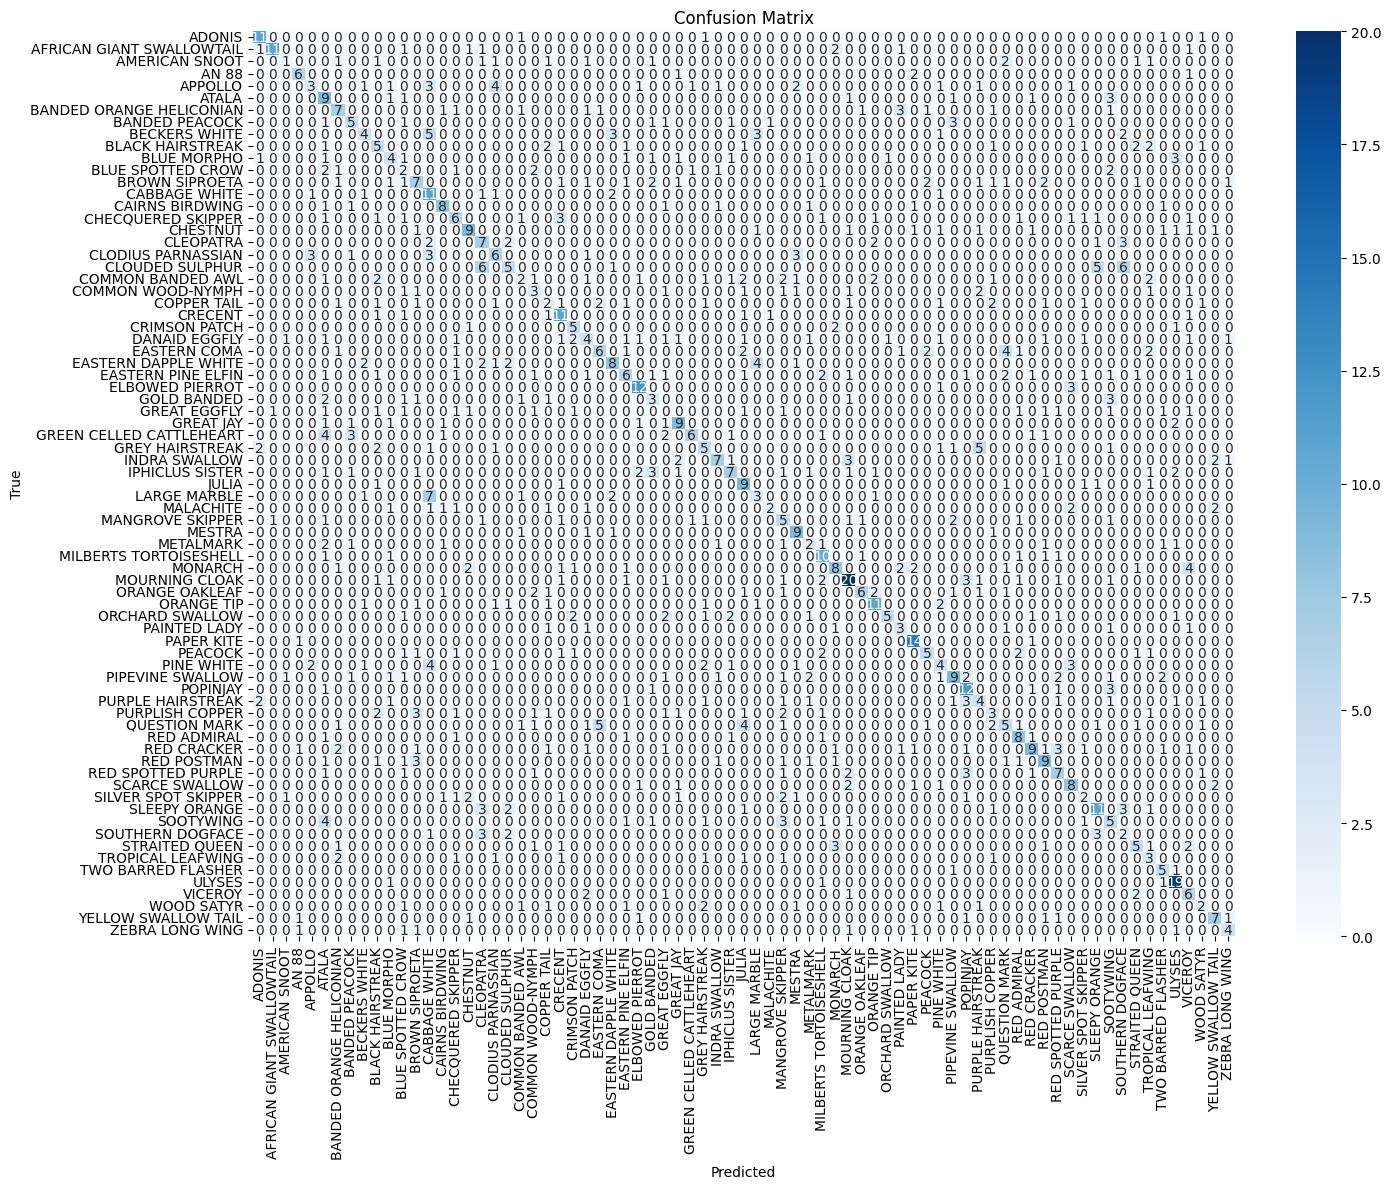

                           precision    recall  f1-score   support

                   ADONIS       0.65      0.73      0.69        15
AFRICAN GIANT SWALLOWTAIL       0.85      0.58      0.69        19
           AMERICAN SNOOT       0.25      0.08      0.12        12
                    AN 88       0.60      0.60      0.60        10
                  APPOLLO       0.33      0.15      0.21        20
                    ATALA       0.23      0.53      0.32        17
 BANDED ORANGE HELICONIAN       0.37      0.37      0.37        19
           BANDED PEACOCK       0.36      0.33      0.34        15
            BECKERS WHITE       0.36      0.22      0.28        18
         BLACK HAIRSTREAK       0.25      0.28      0.26        18
              BLUE MORPHO       0.29      0.25      0.27        16
        BLUE SPOTTED CROW       0.11      0.17      0.13        12
           BROWN SIPROETA       0.32      0.27      0.29        26
            CABBAGE WHITE       0.29      0.61      0.39     

In [23]:
# Generate confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = final_model.predict(X_test_combined)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

Processing image 1/15


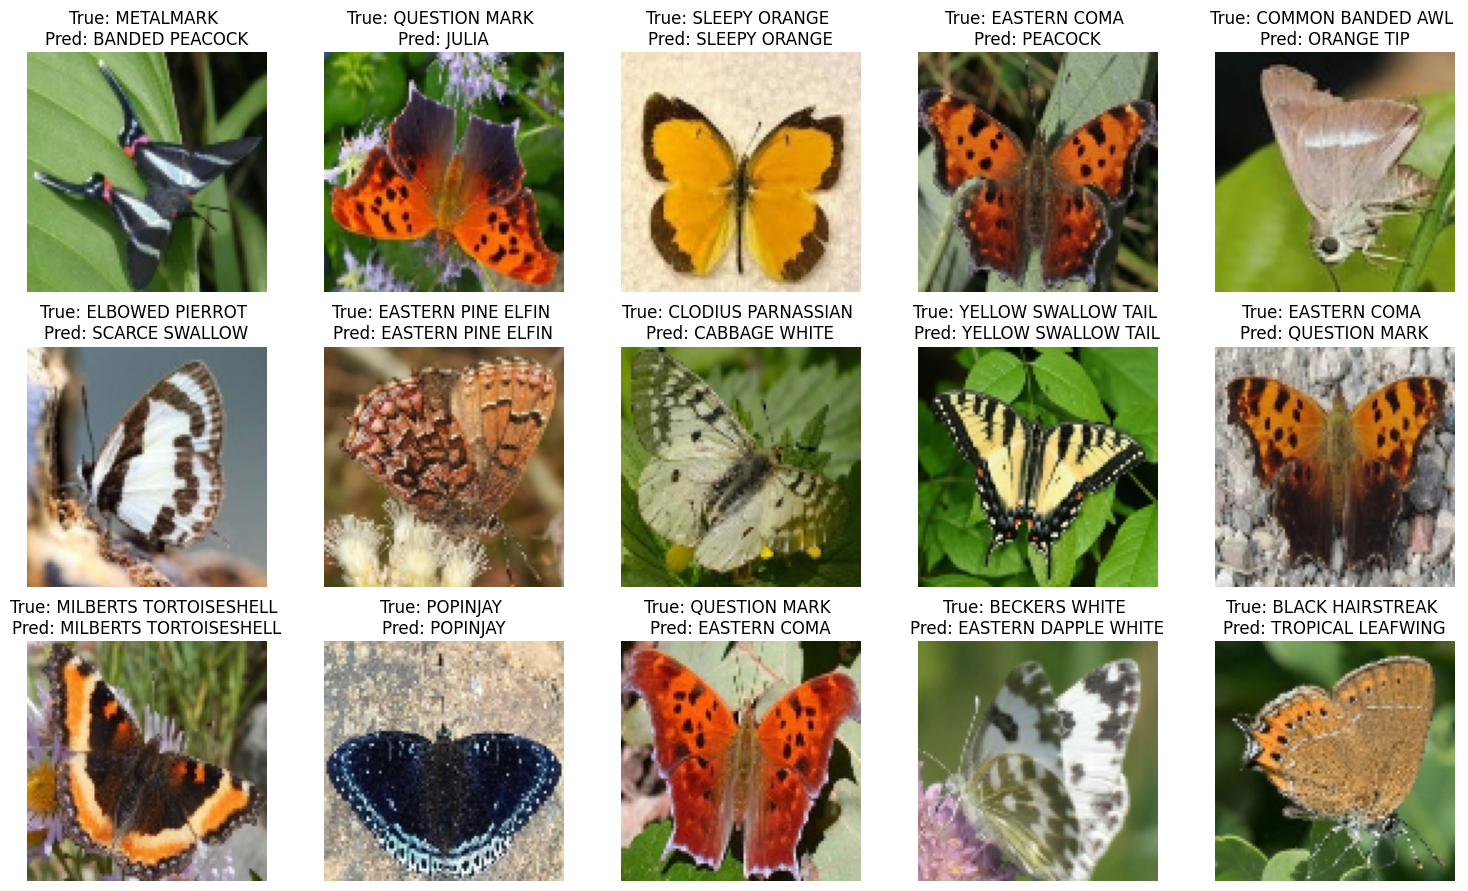

In [31]:
# Show example predictions
show_predictions(final_model, X_test, y_test, class_names, n=15, cols=5)